<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/dataExploring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Animal Data


Load the dataset from '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt' into a pandas DataFrame.
| Variables | Meaning | Note |
| :--- | :--- | :--- |
| Farm_code | Identifier of FARM | |
| Animal_ID | Identifier Animal | |
| DTB | Date of birth of the animal | |
| DTC | Date of calving which provided the lactation | |
| DTT | Date of the test-date/milk quality control | |
| Parity | Parity order | |
| Milk_kg | Quantitiy of milk produced per day in kg during the test | Divide it by 10 |
| Fat_p | Percentage of Fat in the milk during the test-day | Divide it by 100 |
| Protein_p | Percentage of protein in the milk during the test-day | Divide it by 100 |
| cells | N. of cells per ml during the test-day | You will see the N. divided by 100000 |
| NM | N. of milking event per day | Usually 2 per day |

In [1]:
datasetAnimalPath = '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt'

In [2]:
import pandas as pd

# 1. Define your column names
col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

# 2. Read and clean the file line by line
with open(datasetAnimalPath, 'r') as file:
    # Skip the header line
    next(file)

    for line in file:
        # Remove whitespace/newlines from ends
        line = line.strip()

        # Skip empty lines if any exist
        if not line:
            continue

        # Split the line by comma
        parts = line.split(',')

        # LOGIC: Fix the rows based on length
        if len(parts) == 11:
            # This is a correct row, keep it as is
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            # This is a broken row.
            # This leaves one empty slot for 'dtb' and shifts the rest back.
            parts.pop(2)
            cleaned_rows.append(parts)

# 3. Create the DataFrame
df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

# 4. Convert columns to correct types (since they were read as strings)
numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

# 5. Convert Date Columns
date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

# Check the result
print(df_animal.head(5))
print(f"\nTotal rows loaded: {len(df_animal)}")

   Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0     521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1     521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2     521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3     521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4     521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   

   milk_kg  fat_p  protein_p  cells  NM  
0      141    617        484    656   2  
1      168    682        417    827   2  
2      134    763        459   1144   2  
3      108    663        454   1403   2  
4       94    688        451   1805   2  

Total rows loaded: 2593267


In [3]:
df_animal.isnull().sum()

,0
Farm_Code,0
Animal_ID,0
dtb,1873
dtc,0
dtt,0
parity,0
milk_kg,0
fat_p,0
protein_p,0
cells,0


In [4]:
print("Descriptive statistics for numerical columns:")
df_animal.describe()

Descriptive statistics for numerical columns:


,Farm_Code,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,NM
count,2.593267e+06,2591394,2593267,2593267,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06
mean,6.239304e+06,2013-01-15 01:02:46.180518656,2019-02-12 07:56:07.435903232,2019-07-08 02:21:46.675169536,3.379940e+00,9.043340e+01,7.788952e+02,4.567361e+02,2.811822e+02,1.973870e+00
min,5.215130e+05,1985-07-01 00:00:00,2011-05-09 00:00:00,2013-01-02 00:00:00,1.000000e+00,0.000000e+00,-3.870000e+02,-2.370000e+02,0.000000e+00,1.000000e+00
25%,5.700749e+06,2010-01-23 00:00:00,2016-05-11 00:00:00,2016-10-11 00:00:00,1.000000e+00,6.500000e+01,6.720000e+02,4.390000e+02,4.300000e+01,2.000000e+00
50%,6.800300e+06,2013-03-13 00:00:00,2019-11-02 00:00:00,2020-03-09 00:00:00,3.000000e+00,8.700000e+01,7.960000e+02,4.670000e+02,9.600000e+01,2.000000e+00
75%,7.000160e+06,2016-07-06 00:00:00,2021-11-25 00:00:00,2022-04-04 00:00:00,5.000000e+00,1.140000e+02,9.150000e+02,4.980000e+02,2.390000e+02,2.000000e+00
max,9.410250e+06,2021-12-29 00:00:00,2023-12-24 00:00:00,2023-12-29 00:00:00,2.700000e+01,8.860000e+02,7.943000e+03,8.557000e+03,9.814700e+04,3.000000e+00
std,1.538862e+06,NaN,NaN,NaN,2.437515e+00,3.808888e+01,2.387913e+02,9.352945e+01,7.981789e+02,1.717433e-01


### Parameters Analysis

Generating data visualizations for numerical columns...


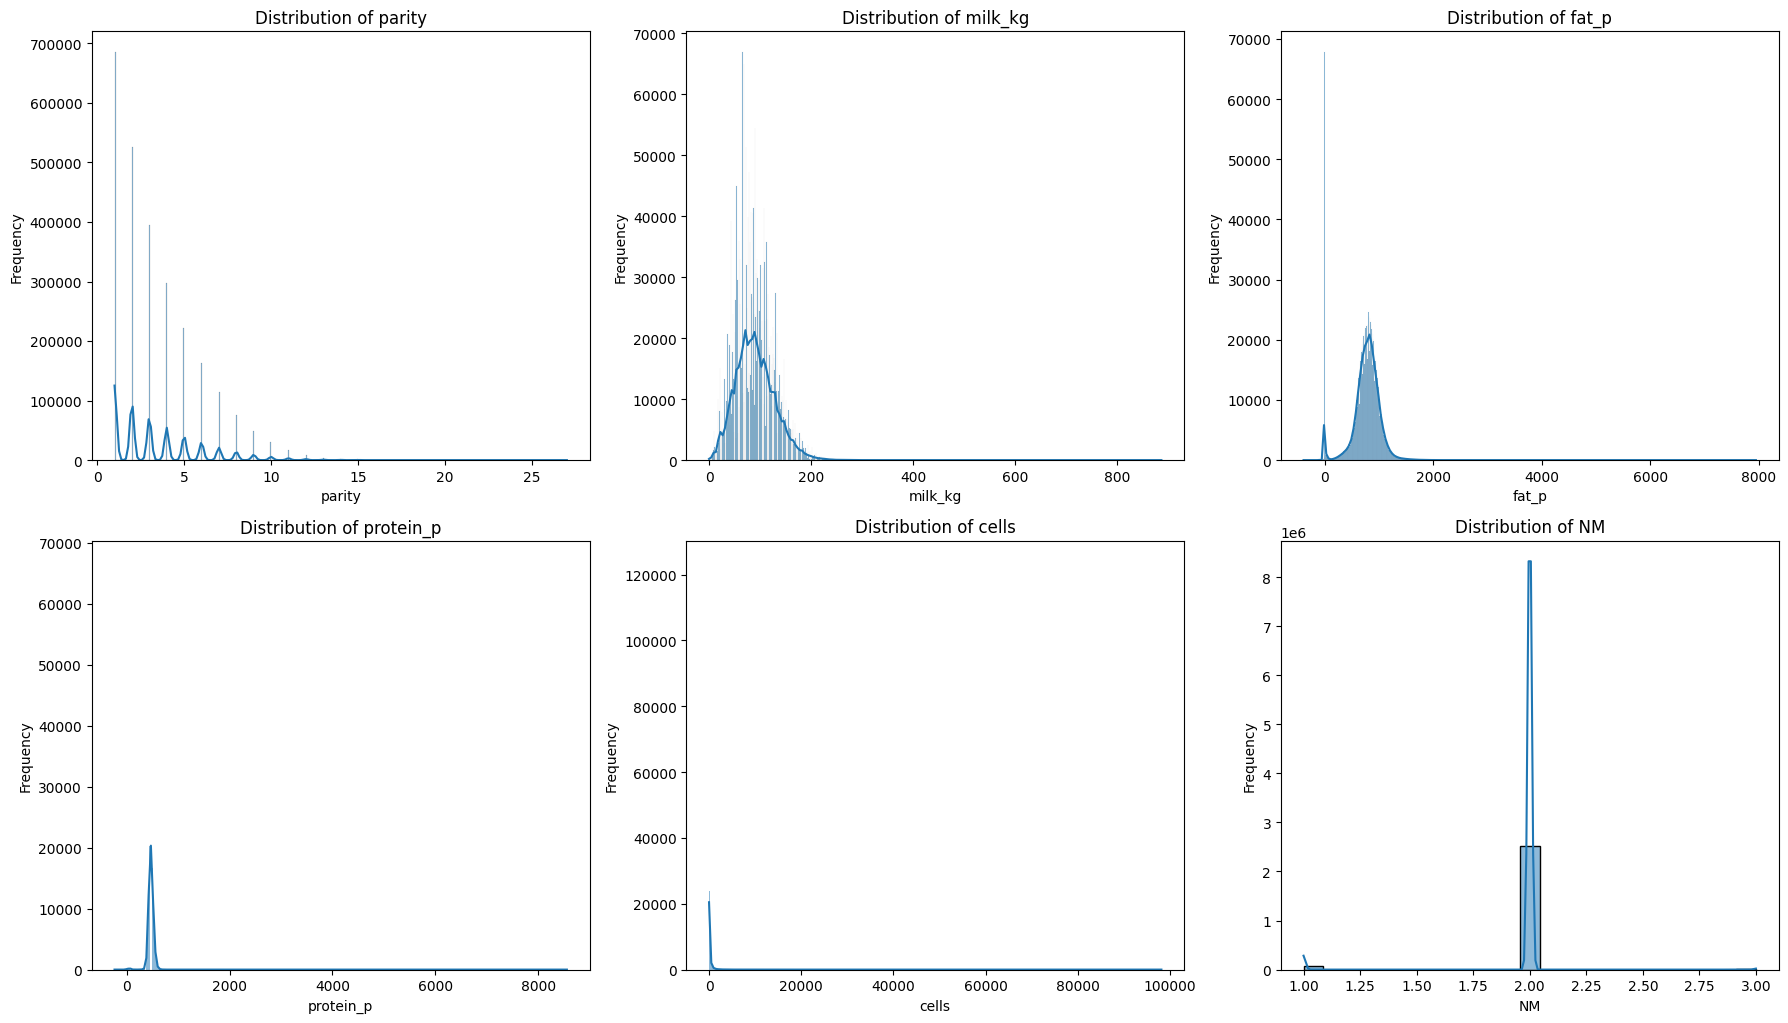

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating data visualizations for numerical columns...")

# Set up the matplotlib figure and axes for subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

# Select numerical columns for visualization, excluding date-like integers and IDs
numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create histograms for numerical columns
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df_animal[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### parity

In [ ]:
df_animal['parity'].quantile([0.01,0.99])

In [ ]:
len(df_animal[(df_animal['parity'] > 11) | (df_animal['parity'] < 1)])

#### milk_kg

In [ ]:
df_animal['milk_kg'].quantile([0.01,0.99])

In [ ]:
len(df_animal[(df_animal['milk_kg'] > 193) | (df_animal['milk_kg'] < 18)])

#### fat_p


In [ ]:
len(df_animal[df_animal['fat_p']==0])

In [ ]:
df_animal['fat_p'].quantile([0.03,0.99])

In [ ]:
len(df_animal[(df_animal['fat_p'] > 1327) | (df_animal['fat_p'] < 36)])

#### protein_p

In [ ]:
len(df_animal[df_animal['protein_p']==0])

In [ ]:
df_animal['protein_p'].quantile([0.03,0.99])

In [ ]:
len(df_animal[(df_animal['protein_p'] > 588) | (df_animal['protein_p'] < 63)])

#### cells

In [ ]:
len(df_animal[df_animal['cells']==0])

In [ ]:
df_animal['cells'].quantile([0.05,0.99])

In [ ]:
len(df_animal[(df_animal['cells'] > 3081) | (df_animal['cells'] < 4)])

#### NM

In [10]:
df_animal['NM'].value_counts()

,count
NM,
2,2515006
1,73012
3,5249


## Load Farm Data
Load the dataset from '/content/drive/MyDrive/Thesis_Data/latitude_and_longitude.xlsx' into a pandas DataFrame.

In [ ]:
datasetFarmPath = '/content/drive/MyDrive/Thesis_Data/latitude and longitude.xlsx'

In [ ]:
import pandas as pd

# 1. Define your column names (assuming Excel has headers, these will be used for verification)
col_names = [
    'Farm_name','Commercial_name','Farm_code','ASL_code','Adress','City','Postal_code','Province','Region','Latitude','Longitude'
]

# 2. Read the Excel file into a DataFrame
df_farm = pd.read_excel(datasetFarmPath)

# Check the result
print(df_farm.head())
print(f"\nTotal rows loaded: {len(df_farm)}")

                 Farm name                       Commercial name  Farm_code  \
0  ABBATE MARIA ANTONIETTA               ABBATE MARIA ANTONIETTA    6811505   
1          BOTTAI LEONARDO  AGRIAMBIENTE MUGELLO SOC. COOP. AGR.    4241329   
2          DIANA VALENTINA              AGRICOLA DIANA VALENTINA    6811588   
3         GIULIANI ALVIDIO             AGRICOLA GIULIANI ALVIDIO    5600136   
4              RUBINO VITO    AGRICOLA LA PESCARA DI VITO RUBINO    6812804   

   ASL_code                                 Adress                      City  \
0  084CE077                          VIA NAZIONALE  SANTA MARIA CAPUA VETERE   
1  004FI004                   VIA DI GALLIANO 15/A      BARBERINO DI MUGELLO   
2  027CE147                     P.CO SAN BENEDETTO           CASTEL VOLTURNO   
3  005FR138                    VIA COLLE COTTO. 37                   AMASENO   
4  068CE017  Via Santa Lucia 3 Loc. Pietre Bianche                    RIARDO   

   Postal_code Province    Region   Latitude

In [ ]:
df_farm.loc[164,'Province'] = 'CA'

### Farms on the Map

In [ ]:
import folium

# Calculate the mean latitude and longitude to center the map
mean_lat = df_farm['Latitude'].mean()
mean_lon = df_farm['Longitude'].mean()

# Create a base map centered around the mean coordinates
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)

# Add a marker for each farm
for index, row in df_farm.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"<b>Farm:</b> {row['Farm name']}<br><b>Code:</b> {row['Farm_code']}",
        tooltip=row['Farm name']
    ).add_to(m)

# Display the map
m